# P605 – PJM Hourly Energy Consumption Forecasting

### Historical Time Series Analysis and 30-Day Forecasting of Energy Consumption


## 1. Problem Statement

Energy consumption varies based on time, season, day of the week, and other
time-dependent factors. Accurate energy consumption forecasting helps
electricity providers plan power generation, manage resources, and maintain
the balance between energy supply and demand.

This project focuses on analyzing historical hourly energy consumption data
from the PJM region and identifying important time-based patterns and trends.
The analysis will be used to develop a forecasting model for predicting
future hourly energy consumption.

## 2. Business Objective

Taken from the project requirement document:

1. Split the **last year of data into a test set** and build a model that predicts energy consumption.
2. Find trends in consumption around **hours of the day, holidays and long-term trends**.
3. Understand how **daily trends change with the time of year** (summer vs. winter).
4. **Forecast the next 30 days.**

Supporting objectives handled in this notebook:

- Check data quality: unsorted rows, duplicate timestamps, missing hours, and outliers.
- Analyse hourly, weekday/weekend, monthly, seasonal, and yearly patterns.
- Quantify the holiday effect.
- Test the series for trend, seasonality and stationarity to guide model selection.

## 3. Dataset Description

The dataset contains historical hourly energy consumption records from the
PJM region.

### Dataset Features

- **Datetime:** Date and time of energy consumption measurement.
- **PJMW_MW:** Energy consumption measured in megawatts (MW).

The dataset is used to analyze historical energy consumption patterns and
develop a time series forecasting model.

## 4. Project Workflow

The project is divided into the following stages:

1. Problem Statement, Business Objective and Dataset Description
2. Import Required Libraries
3. Load the Dataset and Initial Data Inspection
4. Data Cleaning and Preprocessing (sorting, duplicates, missing hours, unrealistic values)
5. Univariate Analysis
6. Time-Based Feature Engineering
7. Time-Based Exploratory Data Analysis (hourly, weekly, monthly, seasonal, long-term, holiday, stationarity)
8. Train-Test Split (last one year as test set)
9. Model Development – Tuned LSTM (scaling, sequences, hyperparameter tuning)
10. Model Evaluation (metrics, loss curves, actual vs predicted)
11. 30-Day Future Energy Consumption Forecast
12. Saving the Model and Scaler for Deployment
13. Limitations and Future Work
14. Conclusion


## 5. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 6. Load the Dataset

The dataset is loaded using pandas for further inspection and analysis.

In [2]:
df = pd.read_excel('PJMW_MW_Hourly.xlsx')
df

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930
...,...,...
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958


### 6.1 Display the First Five Records

The first five records are displayed to understand the structure and
initial values of the dataset.

In [3]:
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


The first displayed record is **2002-12-31**, while the chronological dataset begins in **April 2002**. This indicates that the source file is not initially ordered chronologically, so the data is sorted by `Datetime` before time-series analysis.


### 6.2 Display the Last Five Records

The last five records are displayed to inspect the ending records of
the dataset.

In [4]:
df.tail()

,Datetime,PJMW_MW
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958
143205,2018-01-02 00:00:00,7691


### 6.3 Dataset Information

The information of the dataset is checked to understand the column names,
data types, and non-null values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


### 6.4 Dataset Shape

The number of rows and columns in the dataset is identified.

In [6]:
df.shape

(143206, 2)

The raw dataset contains **143,206 rows and 2 columns**.


### 6.5 Statistical Summary

Descriptive statistics are calculated for the numerical columns to
understand the distribution of energy consumption values.

In [7]:
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


In [8]:
df[['PJMW_MW']].describe()

,PJMW_MW
count,143206.000000
mean,5602.375089
std,979.142872
min,487.000000
25%,4907.000000
50%,5530.000000
75%,6252.000000
max,9594.000000


The minimum consumption is **487 MW**, which is substantially lower than the main demand range. This value is investigated separately as a potential data-quality issue rather than being removed without inspection.


## 7. Data Cleaning and Preprocessing

### 7.1 Checking Missing Values

Missing values are checked to identify incomplete records in the dataset.

In [9]:
df.isnull().sum()

Datetime    0
PJMW_MW     0
dtype: int64

There are no null cells in the file, but time series data can also be missing **whole rows** (missing hours).

### 7.2 Checking Data Types

The data types of all columns are checked to ensure that the columns
are in the appropriate format.

In [10]:
df.dtypes

Datetime    datetime64[ns]
PJMW_MW              int64
dtype: object

`Datetime` is already `datetime64` and `PJMW_MW` is an integer, so no type conversion is needed.

### 7.3 Setting Datetime as the Index and Sorting

The Datetime column is converted into the index to perform time series
analysis efficiently.

In [11]:
df.set_index('Datetime', inplace = True)

df.sort_index(inplace = True)

df.head()

,PJMW_MW
Datetime,
2002-04-01 01:00:00,4374
2002-04-01 02:00:00,4306
2002-04-01 03:00:00,4322
2002-04-01 04:00:00,4359
2002-04-01 05:00:00,4436


### 7.4 Checking Duplicate Timestamps

Each hour should appear exactly once, so repeated timestamps are checked next.

In [12]:
df.index.duplicated().sum()

np.int64(4)

### 7.5 Displaying Duplicate Records

The duplicate timestamp records are displayed for further inspection.

In [13]:
df[df.index.duplicated(keep=False)]

,PJMW_MW
Datetime,
2014-11-02 02:00:00,4571
2014-11-02 02:00:00,4613
2015-11-01 02:00:00,3927
2015-11-01 02:00:00,3832
2016-11-06 02:00:00,4114
2016-11-06 02:00:00,4089
2017-11-05 02:00:00,3984
2017-11-05 02:00:00,4042


The duplicate timestamps occur during the daylight-saving-time clock change, when the 02:00 clock hour can appear twice. These observations are retained initially because both records are valid measurements, and they are handled by averaging duplicate timestamps before enforcing a strict hourly frequency.


### 7.6 Handling Duplicate Timestamps

Because both readings are legitimate measurements of the same clock hour, they are **averaged**
into one value instead of throwing one away.

In [14]:
df = df.groupby(level=0).mean()

print('Duplicate timestamps after handling:', df.index.duplicated().sum())

Duplicate timestamps after handling: 0


In [15]:
df.shape

(143202, 1)

### 7.7 Checking Hourly Frequency and Missing Timestamps

A time series should have exactly one row for every hour. If some hours are absent from the data,
`asfreq('h')` builds a complete hourly index and inserts the absent hours as empty (NaN) values,
so that they can be identified and filled later.

In [16]:
# Convert the data to a strict hourly frequency (missing hours are added as NaN)
df = df.asfreq('h')

print('Total rows after applying hourly frequency:', len(df))
print('Missing values:', df['PJMW_MW'].isnull().sum())

Total rows after applying hourly frequency: 143232
Missing values: 30


### 7.8 Checking Missing Timestamps

Missing timestamps are identified after converting the dataset into
an hourly frequency.

In [17]:
# Display the missing timestamps
df[df['PJMW_MW'].isnull()]

,PJMW_MW
Datetime,
2002-04-07 03:00:00,NaN
2002-10-27 02:00:00,NaN
2003-04-06 03:00:00,NaN
2003-10-26 02:00:00,NaN
2004-04-04 03:00:00,NaN
2004-10-31 02:00:00,NaN
2005-04-03 03:00:00,NaN
2005-10-30 02:00:00,NaN
2006-04-02 03:00:00,NaN


After converting the series to a strict hourly frequency, **30 missing hourly timestamps** are identified. These represent missing observations in the source time series rather than null cells in the original file.


### 7.9 Handling Missing Values

The missing hourly timestamps were added as empty (NaN) rows by `asfreq('h')`. Since every missing hour
is a single isolated hour, time-based linear interpolation is used to fill them. The value is estimated
from the hours just before and after the gap.

In [18]:
# Fill the missing hours using time-based linear interpolation
df['PJMW_MW'] = df['PJMW_MW'].interpolate(method='time')

print('Missing values after interpolation:', df['PJMW_MW'].isnull().sum())

Missing values after interpolation: 0


### 7.10 Handling Unrealistic Values

The minimum value in the data is 487 MW, while normal demand is between about 3,000 and 9,600 MW.
This single reading is a recording error, so it is replaced using interpolation.

In [19]:
# Display the unrealistic value
df[df['PJMW_MW'] < 1000]

,PJMW_MW
Datetime,
2003-05-29,487.0


The value of **487 MW** is treated as a data-quality anomaly because it is far below the surrounding demand values and occurs only once. Instead of deleting the observation, it is replaced with a missing value and estimated using time-based interpolation from neighboring observations.


In [20]:
# Mark the unrealistic value as missing, then fill it by interpolation
df.loc[df['PJMW_MW'] < 1000, 'PJMW_MW'] = np.nan
df['PJMW_MW'] = df['PJMW_MW'].interpolate(method='time')

print('Missing values:', df['PJMW_MW'].isnull().sum())
print('Total rows:', len(df))
print('Frequency:', df.index.freq)

Missing values: 0
Total rows: 143232
Frequency: <Hour>


In [21]:
df.shape

(143232, 1)

## 8. Univariate Analysis (Visualizing Distribution & Outliers)

### 8.1 Distribution of Energy Consumption

A histogram is used to understand the distribution of hourly energy
consumption values and identify the overall spread of the data.

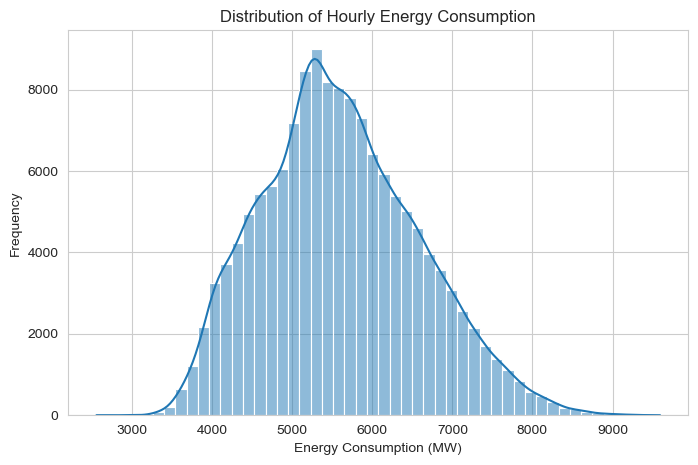

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['PJMW_MW'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Hourly Energy Consumption')
plt.xlabel('Energy Consumption (MW)')
plt.ylabel('Frequency')
plt.show()

The histogram shows the distribution of hourly energy consumption measured in MW.

##### Observations:
- The majority of the energy consumption values are concentrated between approximately 4,500 MW and 7,000 MW.
- The distribution reaches its highest frequency around 5,200–5,500 MW.
- The distribution is slightly right-skewed, with a longer tail extending toward higher consumption values.
- Very low consumption values below approximately 3,500 MW and very high values above 8,000 MW occur less frequently.
- Overall, the histogram provides an understanding of the typical range and distribution of hourly energy consumption.

The energy consumption data is mainly concentrated around the 5,000–6,000 MW range, while extreme high and low consumption values occur relatively less frequently.

### 8.2 Box Plot of Energy Consumption

A box plot is used to identify the median, spread, and potential
outliers in the energy consumption data.

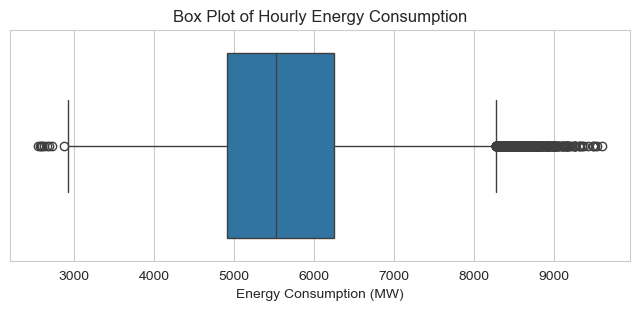

In [23]:
plt.figure(figsize=(8, 3))

sns.boxplot(
    x=df['PJMW_MW'].dropna()
)

plt.title('Box Plot of Hourly Energy Consumption')
plt.xlabel('Energy Consumption (MW)')
plt.show()

The box plot shows the distribution, variability, and potential outliers in hourly energy consumption measured in MW.

##### Observations:
- The median energy consumption is approximately 5,500 MW.
- The middle 50% of the observations (IQR) lies approximately between 4,900 MW and 6,200 MW.
- The majority of the consumption values fall within the range of approximately 3,000 MW to 8,200 MW.
- Several low-end and high-end outliers are visible outside the whiskers.
- The high-end outliers extend beyond 8,200 MW, while a smaller number of low-end outliers occur below approximately 3,000 MW.
- The presence of these outliers indicates that energy consumption occasionally reaches unusually low or high levels.

The hourly energy consumption is mainly concentrated around the 5,000–6,200 MW range, with some extreme values on both ends. These outliers should be considered during further analysis and model building.

## 9. Time-Based Feature Engineering

Time-based features are created from the datetime index to analyze how energy consumption varies by hour, day of the week, month, season, and holiday.

These features will help identify daily, weekly, seasonal, and yearly consumption patterns.

In [24]:
# Create time-based features

df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['DayName'] = df.index.day_name()
df['Month'] = df.index.month
df['MonthName'] = df.index.month_name()
df['Year'] = df.index.year
df['IsWeekend'] = df['DayOfWeek'] >= 5

# Create season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

df.head()

,PJMW_MW,Hour,DayOfWeek,DayName,Month,MonthName,Year,IsWeekend,Season
Datetime,,,,,,,,,
2002-04-01 01:00:00,4374.0,1,0,Monday,4,April,2002,False,Spring
2002-04-01 02:00:00,4306.0,2,0,Monday,4,April,2002,False,Spring
2002-04-01 03:00:00,4322.0,3,0,Monday,4,April,2002,False,Spring
2002-04-01 04:00:00,4359.0,4,0,Monday,4,April,2002,False,Spring
2002-04-01 05:00:00,4436.0,5,0,Monday,4,April,2002,False,Spring


## 10. Time-Based EDA

The time-based features created above are now used to analyze how energy consumption varies by hour, day of week, month, season, holiday, and over the long term.

### 10.1 Average Energy Consumption by Hour

The hourly consumption pattern is analyzed to understand how electricity demand changes throughout the day.

Average consumption is calculated for each hour from 00:00 to 23:00.

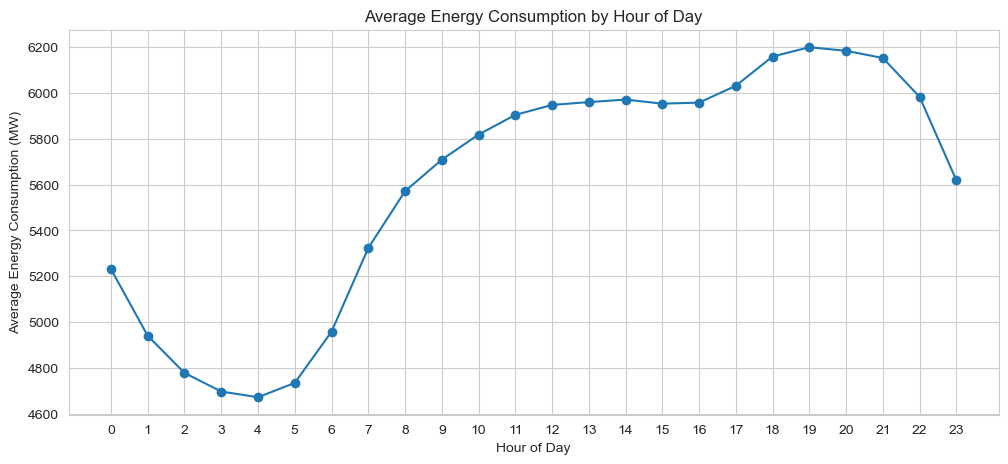

In [25]:
hourly_avg = df.groupby('Hour')['PJMW_MW'].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker='o'
)

plt.title('Average Energy Consumption by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (MW)')
plt.xticks(range(24))
plt.grid(True)
plt.show()

#### Observation

The hourly energy consumption shows a clear daily pattern.

- The lowest average consumption occurs at **4:00 AM**, at approximately **4,672.54 MW**.
- Consumption gradually increases after the early morning hours.
- Demand reaches its highest average level at **7:00 PM**, at approximately **6,199.29 MW**.
- After the evening peak, consumption gradually decreases toward midnight.


Energy consumption varies significantly throughout the day, with lower demand during the early morning hours and higher demand during the evening.

This indicates that **hour of the day is an important time-based factor** for understanding and forecasting PJM energy consumption.

### 10.2 Average Energy Consumption by Day of Week

The average energy consumption is analyzed across the seven days of the week to identify weekly consumption patterns.

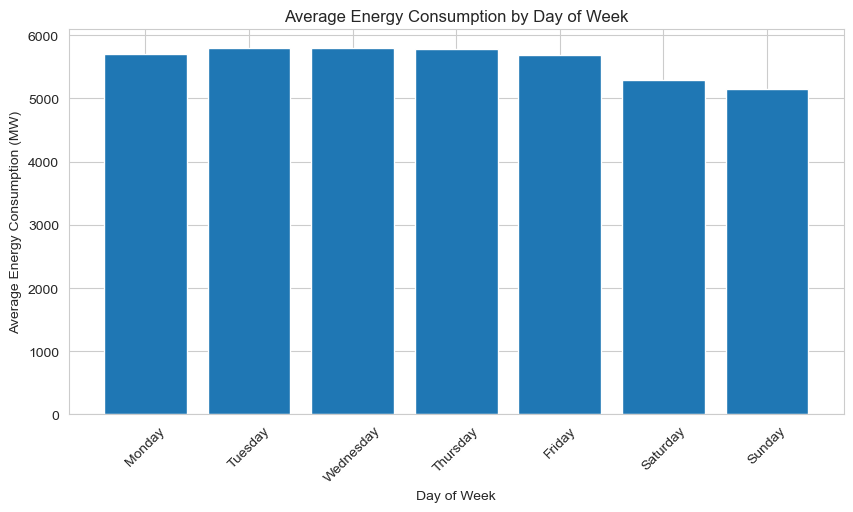

In [26]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_avg = df.groupby('DayName')['PJMW_MW'].mean().reindex(day_order)

plt.figure(figsize=(10, 5))

plt.bar(
    daily_avg.index,
    daily_avg.values
)

plt.title('Average Energy Consumption by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy Consumption (MW)')
plt.xticks(rotation=45)
plt.show()

#### Observation

The average energy consumption varies across the days of the week.

- **Wednesday** has the highest average consumption at approximately **5,802.37 MW**.
- **Sunday** has the lowest average consumption at approximately **5,149.02 MW**.
- Consumption is generally higher during the working days from Monday to Friday.
- Consumption decreases noticeably during Saturday and Sunday.

The data shows a clear weekly consumption pattern, with lower average demand on weekends compared with most weekdays.

Therefore, **day of the week is an important factor** to consider when analyzing and forecasting energy consumption.

### 10.3 Weekday vs Weekend Energy Consumption

Energy consumption is compared between weekdays and weekends to identify differences in demand patterns.

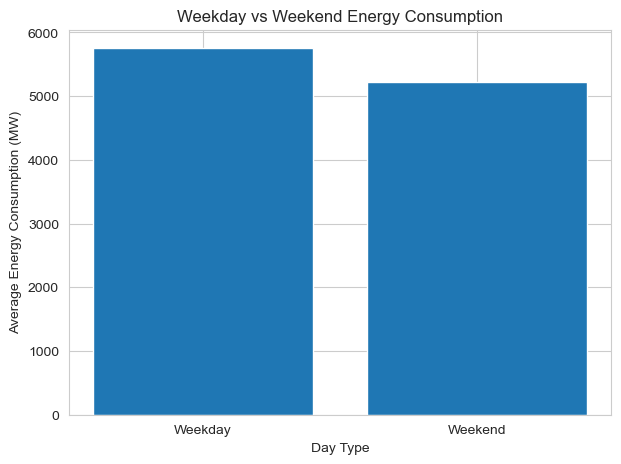

In [27]:
weekday_weekend_avg = df.groupby('IsWeekend')['PJMW_MW'].mean()

labels = ['Weekday', 'Weekend']

values = [
    weekday_weekend_avg[False],
    weekday_weekend_avg[True]
]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.title('Weekday vs Weekend Energy Consumption')
plt.xlabel('Day Type')
plt.ylabel('Average Energy Consumption (MW)')
plt.show()

#### Observation

The comparison between weekdays and weekends shows a clear difference in average energy consumption.

- Average weekday consumption is approximately **5,754.40 MW**.
- Average weekend consumption is approximately **5,221.51 MW**.
- Weekday consumption is approximately **532.89 MW higher** than weekend consumption.


Energy consumption is approximately **10.21% higher on weekdays than on weekends**.

This indicates that weekday/weekend classification captures an important variation in electricity demand and can be useful as a forecasting feature.

### 10.4 Average Energy Consumption by Month

Monthly average energy consumption is analyzed to identify changes in electricity demand throughout the year.

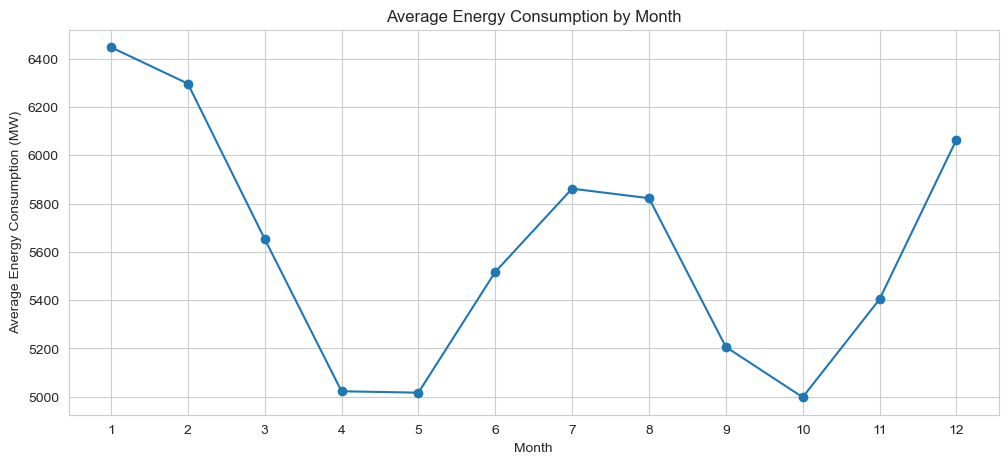

In [28]:
monthly_avg = df.groupby('Month')['PJMW_MW'].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o'
)

plt.title('Average Energy Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption (MW)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

#### Observation

The monthly analysis shows significant variation in average energy consumption throughout the year.

- **January** has the highest average consumption at approximately **6,447.67 MW**.
- **October** has the lowest average consumption at approximately **4,997.37 MW**.
- Consumption is relatively high during the winter months, particularly January, February, and December.
- Consumption decreases during the spring period and increases again during the summer months.


The monthly pattern indicates a strong seasonal component in energy consumption.

Energy demand changes considerably throughout the year, suggesting that **month and season are important factors** for forecasting electricity consumption.

### 10.5 Average Energy Consumption by Season

The data is grouped into four seasons—Winter, Spring, Summer, and Autumn—to understand how energy consumption varies across the year.

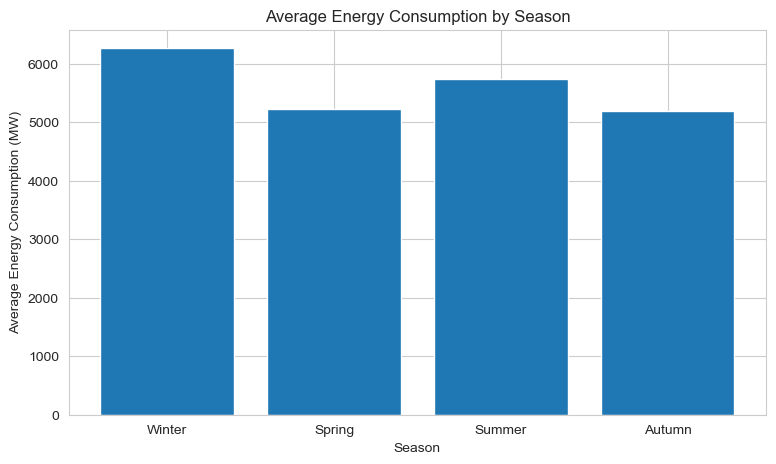

In [29]:
season_order = [
    'Winter',
    'Spring',
    'Summer',
    'Autumn'
]

season_avg = df.groupby('Season')['PJMW_MW'].mean().reindex(season_order)

plt.figure(figsize=(9, 5))

plt.bar(
    season_avg.index,
    season_avg.values
)

plt.title('Average Energy Consumption by Season')
plt.xlabel('Season')
plt.ylabel('Average Energy Consumption (MW)')
plt.show()

#### Observation

The seasonal analysis shows clear differences in average energy consumption across the four seasons.

- **Winter** has the highest average consumption at approximately **6,268.82 MW**.
- **Summer** has the second-highest average consumption at approximately **5,734.21 MW**.
- **Spring** has an average consumption of approximately **5,224.31 MW**.
- **Autumn** has the lowest average consumption at approximately **5,199.95 MW**.


Energy consumption varies substantially with the season.

The higher average consumption observed during Winter and Summer compared with Spring and Autumn indicates that **seasonality is an important component of the PJM energy consumption series**.

### 10.6 Summer vs Winter Daily Consumption Pattern

The hourly consumption patterns during Summer and Winter are compared to understand how the daily demand profile changes with the time of year.

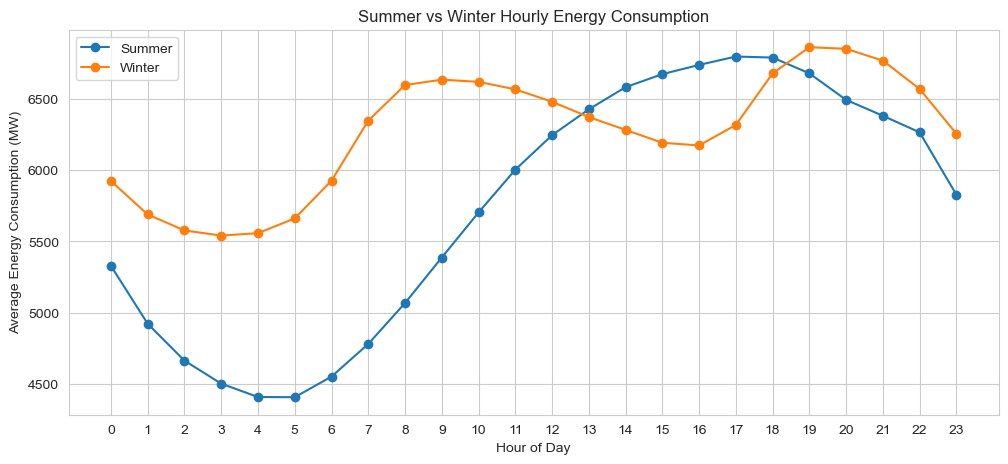

In [30]:
summer = (
    df[df['Season'] == 'Summer']
    .groupby('Hour')['PJMW_MW']
    .mean()
)

winter = (
    df[df['Season'] == 'Winter']
    .groupby('Hour')['PJMW_MW']
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    summer.index,
    summer.values,
    marker='o',
    label='Summer'
)

plt.plot(
    winter.index,
    winter.values,
    marker='o',
    label='Winter'
)

plt.title('Summer vs Winter Hourly Energy Consumption')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (MW)')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

#### Observation

The hourly energy consumption patterns during Summer and Winter are clearly different.

#### Summer Pattern
- Consumption is lowest around **5:00 AM**, at approximately **4,405.76 MW**.
- Demand increases significantly during the day.
- The highest Summer consumption occurs around **5:00 PM**, reaching approximately **6,797.78 MW**.
- After the evening peak, consumption gradually decreases.

#### Winter Pattern
- Consumption is lowest around **3:00 AM**, at approximately **5,540.66 MW**.
- Consumption remains relatively high during the morning hours.
- The highest Winter consumption occurs around **7:00 PM**, reaching approximately **6,863.18 MW**.


The daily consumption profile changes with the season.

Winter shows a generally higher level of energy consumption throughout the day, while Summer shows a stronger increase in demand during the afternoon and evening.

This confirms that **seasonal information combined with hour of day is important for understanding the energy consumption pattern**.

### 10.7 Long-Term Energy Consumption Trend

Monthly average energy consumption is used to analyze the long-term trend in electricity demand across the available historical period.

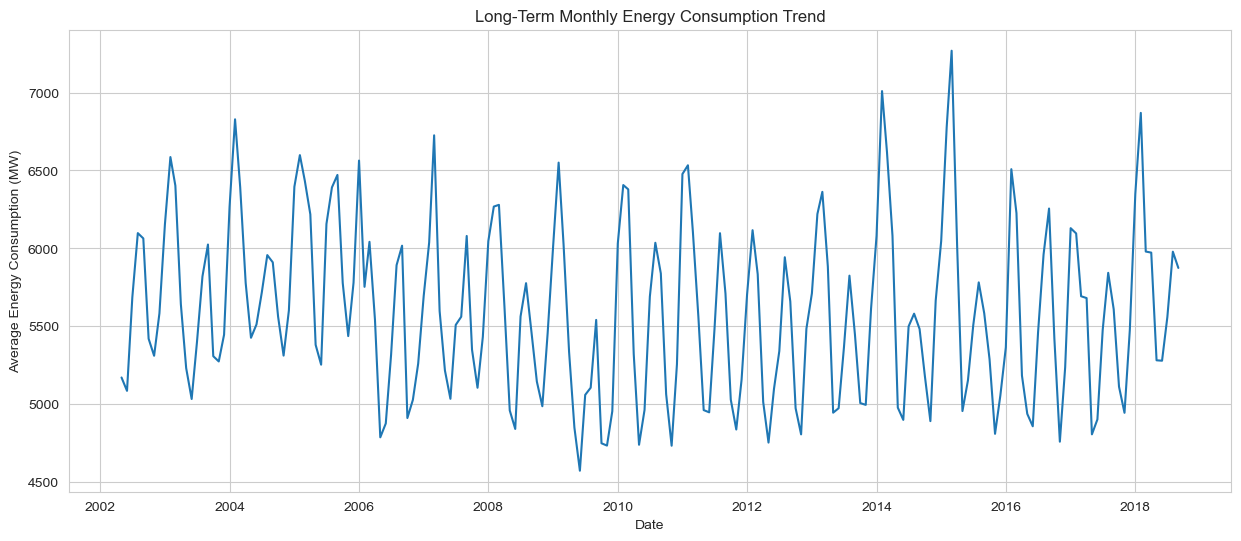

In [31]:
monthly_trend = df['PJMW_MW'].resample('ME').mean()

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_trend.index,
    monthly_trend.values
)

plt.title('Long-Term Monthly Energy Consumption Trend')
plt.xlabel('Date')
plt.ylabel('Average Energy Consumption (MW)')
plt.grid(True)
plt.show()

#### Observation

The long-term monthly trend shows considerable variation in average energy consumption across the historical period.

- The lowest monthly average consumption occurs around **May 2009**, at approximately **4,572.25 MW**.
- The highest monthly average occurs around **February 2015**, at approximately **7,269.06 MW**.
- The consumption level varies substantially across different periods rather than following a continuously increasing or decreasing pattern.
- The final available period in the dataset shows an average monthly consumption of approximately **5,874.35 MW**.


The long-term analysis indicates that PJM energy consumption contains significant temporal variation along with seasonal fluctuations.

Therefore, forecasting models need to account for both **long-term changes and recurring seasonal patterns** in the historical data.

### 10.8 Holiday vs Non-Holiday Energy Consumption

Energy consumption on U.S. federal holidays is compared with consumption on non-holiday days to identify whether holidays are associated with changes in electricity demand.

The U.S. federal holiday calendar is used because the PJM dataset represents electricity consumption in the United States.

In [32]:
from pandas.tseries.holiday import USFederalHolidayCalendar

# Generate U.S. federal holidays for the dataset period
calendar = USFederalHolidayCalendar()

holidays = calendar.holidays(
    start=df.index.min().normalize(),
    end=df.index.max().normalize()
)

# Create holiday indicator
df['IsHoliday'] = df.index.normalize().isin(holidays)

df[['PJMW_MW', 'IsHoliday']].head() 

,PJMW_MW,IsHoliday
Datetime,,
2002-04-01 01:00:00,4374.0,False
2002-04-01 02:00:00,4306.0,False
2002-04-01 03:00:00,4322.0,False
2002-04-01 04:00:00,4359.0,False
2002-04-01 05:00:00,4436.0,False


#### Holiday Consumption Comparison

The average energy consumption is calculated separately for holidays and non-holidays to quantify the difference in demand between the two groups.

In [33]:
holiday_avg = df.groupby('IsHoliday')['PJMW_MW'].mean()

print('Average consumption on non-holidays:',
      holiday_avg[False])

print('Average consumption on holidays:',
      holiday_avg[True])

Average consumption on non-holidays: 5604.612760506373
Average consumption on holidays: 5517.403034979424


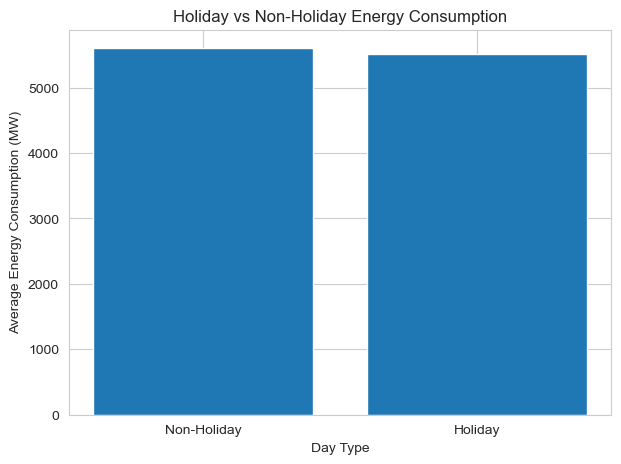

In [34]:
plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-Holiday', 'Holiday'],
    [
        holiday_avg[False],
        holiday_avg[True]
    ]
)

plt.title('Holiday vs Non-Holiday Energy Consumption')
plt.xlabel('Day Type')
plt.ylabel('Average Energy Consumption (MW)')
plt.show()

#### Observation

The comparison between U.S. federal holidays and non-holidays shows a difference in average energy consumption.

- Average consumption on **non-holidays** is approximately **5,604.61 MW**.
- Average consumption on **holidays** is approximately **5,517.40 MW**.
- Holiday consumption is approximately **87.21 MW lower** than non-holiday consumption.
- This represents a decrease of approximately **1.56%** compared with the non-holiday average.


The analysis indicates that energy consumption is slightly lower on U.S. federal holidays than on non-holidays in this dataset.

Therefore, **holiday status can be considered a potentially useful time-based feature** when developing the forecasting model.

### 10.9 Stationarity and Seasonality Check

Before moving to forecasting, the series is checked for stationarity and 
seasonality using the Augmented Dickey-Fuller (ADF) test and seasonal 
decomposition. This helps determine whether differencing or de-seasonalizing 
is required before model building.

In [35]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [36]:
result = adfuller(df['PJMW_MW'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

if result[1] <= 0.05:
    print('\nResult: The series is stationary (reject H0).')
else:
    print('\nResult: The series is non-stationary (fail to reject H0).')

ADF Statistic: -19.947104292294576
p-value: 0.0
Critical Values:
   1%: -3.4303956800384174
   5%: -2.861560189928386
   10%: -2.5667807463806995

Result: The series is stationary (reject H0).


#### Observation

- The ADF test p-value is 0.0, which is well below 0.05.
- The ADF statistic (-19.95) is more negative than all critical values 
  (1%, 5%, 10%), providing strong evidence against the null hypothesis.
- The ADF test rejects the null hypothesis of a unit root at the 5% significance level, providing evidence of stationarity under the ADF test. However, the series still contains strong daily and weekly seasonal patterns, as shown by the time-based analysis and decomposition.

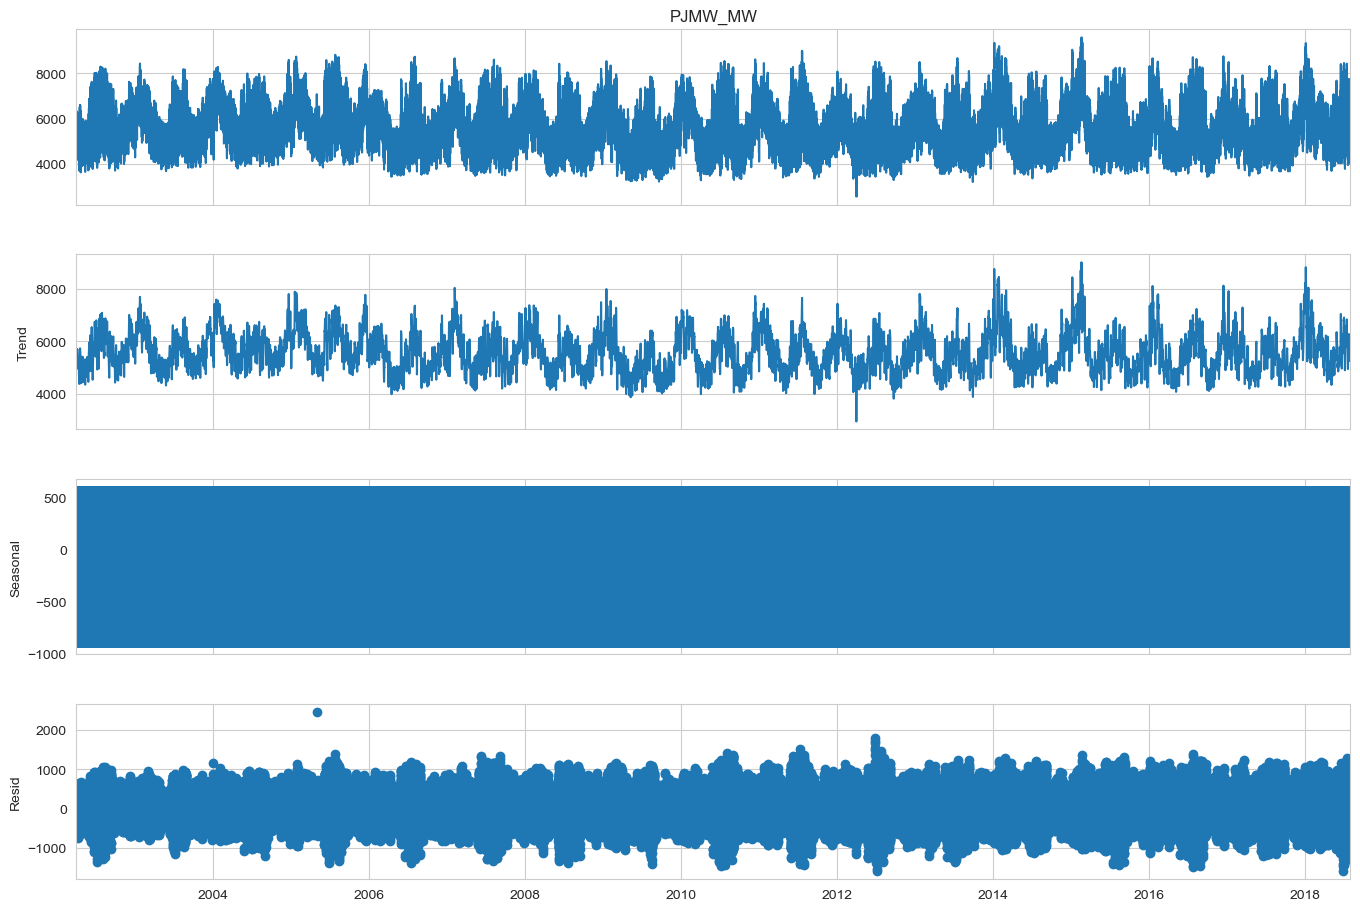

In [37]:
decomposition = seasonal_decompose(
    df['PJMW_MW'],
    model='additive',
    period=24   # 24 hours = one daily cycle
)

fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.show()

#### Observation

- The decomposition confirms a repeating daily (24-hour) seasonal pattern; 
  it appears as a dense block at this scale due to the large number of 
  cycles (16+ years) plotted together.
- The trend component still shows wave-like variation, consistent with the 
  weekly (weekday vs weekend) pattern observed earlier, since only the 
  24-hour seasonal component was removed.
- One notable residual outlier appears around mid-2005. Checking the data 
  confirmed this corresponds to a genuine high-demand period 
  (e.g., 2005-07-26, ~8,800 MW) driven by seasonal extremes (winter cold / 
  summer heat), not a data error, and was therefore retained.


The series shows both daily and weekly seasonal structure along with a 
long-term trend, while remaining statistically stationary per the ADF test. 
This supports using a model that explicitly accounts for seasonality rather than a simple 
trend-only approach.

## EDA Summary

The PJM energy consumption dataset was cleaned and analyzed to understand 
electricity usage patterns over time.

The major findings from the exploratory data analysis are:

* Energy consumption varies across different hours of the day.
* Weekday energy consumption is generally higher than weekend consumption.
* Monthly and seasonal variations are observed in energy usage.
* Summer and winter show different hourly consumption patterns.
* Energy consumption differs between holidays and non-holidays.
* Long-term variations in energy consumption are observed over the years.
* The series is statistically stationary (ADF test), but shows strong 
  daily and weekly seasonality (seasonal decomposition).
* A small number of extreme high-demand readings occur during winter and 
  summer months and were retained as genuine seasonal peaks, while a single 
  physically implausible low reading was treated as a recording error and 
  corrected.

The EDA helped identify important time-based patterns, understand the data 
quality, and prepare the dataset for forecasting.

These findings will be used in the next phase, **Time Series Forecasting and Model Building**, to develop and evaluate suitable forecasting models.

## 11. Train-Test Split

The dataset is split chronologically into training and testing sets.

As required, the **last one year of data is reserved as the test set**, while all previous observations are used for training.

This time-based split is appropriate for forecasting because future observations should not be used to train the model.

In [38]:
test_start = df.index.max() - pd.DateOffset(years=1)

train = df[df.index < test_start].copy()
test = df[df.index >= test_start].copy()

print("Training data:")
print(train.index.min(), "to", train.index.max())
print("Rows:", len(train))

print("\nTesting data:")
print(test.index.min(), "to", test.index.max())
print("Rows:", len(test))

Training data:
2002-04-01 01:00:00 to 2017-08-02 23:00:00
Rows: 134471

Testing data:
2017-08-03 00:00:00 to 2018-08-03 00:00:00
Rows: 8761


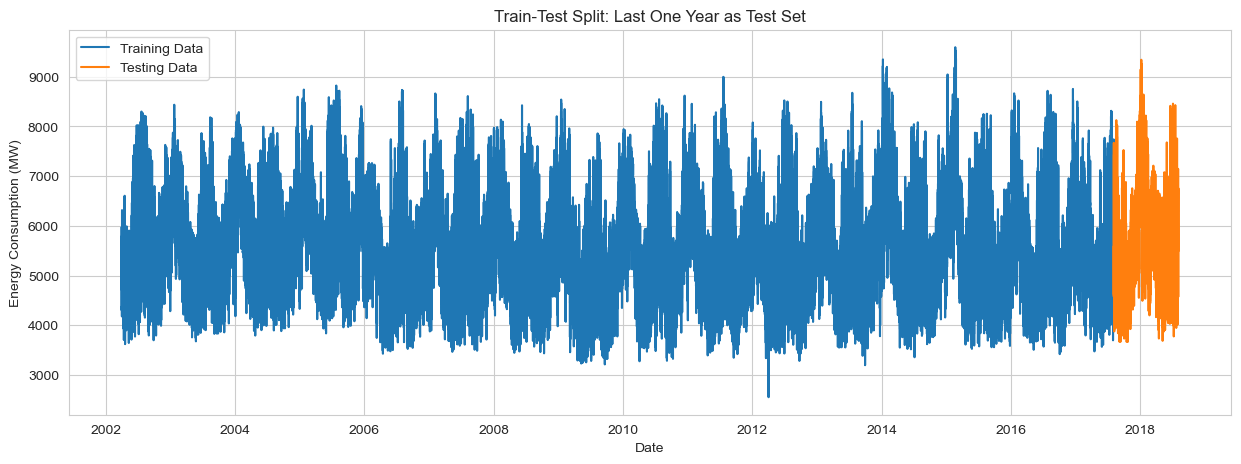

In [39]:
plt.figure(figsize=(15, 5))

plt.plot(train.index, train['PJMW_MW'], label='Training Data')
plt.plot(test.index, test['PJMW_MW'], label='Testing Data')

plt.title('Train-Test Split: Last One Year as Test Set')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.grid(True)
plt.show()

## 12. Model Development – Tuned LSTM

A **Long Short-Term Memory (LSTM)** network is used as the forecasting model for this project. From this point onward, the notebook covers scaling, sequence creation, hyperparameter tuning, evaluation, and future forecasting using the tuned LSTM.

LSTM is a recurrent neural network designed to learn patterns and dependencies in sequential data. It is suitable for hourly energy consumption forecasting because the series contains recurring daily patterns and temporal dependencies.

The model uses the previous **24 hours** of energy consumption to predict the next hour. The data is first scaled, hyperparameters are tuned using a validation split, and the final model is then trained with the best configuration.

### Min-Max Scaling

In [40]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [41]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[['PJMW_MW']])
test_scaled = scaler.transform(test[['PJMW_MW']])

train_scaled = pd.DataFrame(train_scaled, columns=['PJMW_MW'], index=train.index)
print("Scaled Training DataFrame:")
print(train_scaled.head())

test_scaled = pd.DataFrame(test_scaled, columns=['PJMW_MW'], index=test.index)
print("\nScaled Testing DataFrame:")
print(test_scaled.head())

print("\nTraining shape:", train_scaled.shape)
print("Testing shape:", test_scaled.shape)


Scaled Training DataFrame:
                      PJMW_MW
Datetime                     
2002-04-01 01:00:00  0.258628
2002-04-01 02:00:00  0.248970
2002-04-01 03:00:00  0.251243
2002-04-01 04:00:00  0.256498
2002-04-01 05:00:00  0.267434

Scaled Testing DataFrame:
                      PJMW_MW
Datetime                     
2017-08-03 00:00:00  0.431473
2017-08-03 01:00:00  0.371680
2017-08-03 02:00:00  0.340151
2017-08-03 03:00:00  0.304928
2017-08-03 04:00:00  0.291578

Training shape: (134471, 1)
Testing shape: (8761, 1)


### Creating Sequences

The LSTM model uses the previous 24 hours of energy consumption to predict the next hour.

In [42]:
def create_sequences(data, time_steps=24):
    data = data.values

    X = []
    y = []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)


# Training sequences
X_train, y_train = create_sequences(
    train_scaled,
    24
)

# Test sequences using the last 24 training observations
test_input = pd.concat([
    train_scaled.iloc[-24:],
    test_scaled
])

X_test, y_test = create_sequences(
    test_input,
    24
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (134447, 24)
y_train shape: (134447,)
X_test shape: (8761, 24)
y_test shape: (8761,)


In [43]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (134447, 24, 1)
X_test: (8761, 24, 1)


## 12.1 LSTM Hyperparameter Tuning

Hyperparameter tuning is performed to identify the LSTM configuration that gives the lowest validation loss. The parameters tested are the number of LSTM units, batch size, and learning rate.


### Define Hyperparameter Combinations

Different combinations of LSTM units, batch sizes, and learning rates are tested to identify a suitable configuration.

In [44]:
from tensorflow.keras.optimizers import Adam

results = []

units_list = [32, 64]
batch_sizes = [32, 64]
learning_rates = [0.001, 0.01]

### Train Tuned LSTM Models

Each hyperparameter combination is trained and its validation loss is recorded. The configuration with the lowest validation loss is selected for the final model.


In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
for units in units_list:
    for batch_size in batch_sizes:
        for lr in learning_rates:

            model_tuned = Sequential()

            model_tuned.add(
                LSTM(
                    units,
                    input_shape=(24, 1)
                )
            )

            model_tuned.add(Dense(1))

            model_tuned.compile(
                optimizer=Adam(learning_rate=lr),
                loss='mse'
            )

            history_tuned = model_tuned.fit(
                X_train,
                y_train,
                epochs=5,
                batch_size=batch_size,
                validation_split=0.2,
                verbose=0
            )

            val_loss = min(history_tuned.history['val_loss'])

            results.append([
                units,
                batch_size,
                lr,
                val_loss
            ])

            print(
                "Units:", units,
                "| Batch Size:", batch_size,
                "| Learning Rate:", lr,
                "| Validation Loss:", val_loss
            )

Units: 32 | Batch Size: 32 | Learning Rate: 0.001 | Validation Loss: 0.0001808263041311875
Units: 32 | Batch Size: 32 | Learning Rate: 0.01 | Validation Loss: 0.0001538628712296486
Units: 32 | Batch Size: 64 | Learning Rate: 0.001 | Validation Loss: 0.00019925838569179177
Units: 32 | Batch Size: 64 | Learning Rate: 0.01 | Validation Loss: 0.00015497046115342528
Units: 64 | Batch Size: 32 | Learning Rate: 0.001 | Validation Loss: 0.00019024360517505556
Units: 64 | Batch Size: 32 | Learning Rate: 0.01 | Validation Loss: 0.00015483223251067102
Units: 64 | Batch Size: 64 | Learning Rate: 0.001 | Validation Loss: 0.00018717545026447624
Units: 64 | Batch Size: 64 | Learning Rate: 0.01 | Validation Loss: 0.00014284027565736324


### Hyperparameter Tuning Results

The validation loss obtained from each hyperparameter combination is compared to identify the configuration with the lowest validation loss.

In [46]:
import pandas as pd

tuning_results = pd.DataFrame(
    results,
    columns=[
        'Units',
        'Batch Size',
        'Learning Rate',
        'Validation Loss'
    ]
)

tuning_results

,Units,Batch Size,Learning Rate,Validation Loss
0,32,32,0.001,0.000181
1,32,32,0.010,0.000154
2,32,64,0.001,0.000199
3,32,64,0.010,0.000155
4,64,32,0.001,0.000190
5,64,32,0.010,0.000155
6,64,64,0.001,0.000187
7,64,64,0.010,0.000143


Eight combinations of LSTM units, batch size, and learning rate were evaluated using validation loss, with each configuration trained for 5 epochs.

In the recorded tuning run, the lowest validation loss was approximately **0.000148**, corresponding to:

- **LSTM Units:** 64
- **Batch Size:** 64
- **Learning Rate:** 0.01

This configuration was selected for the final LSTM training. Because neural-network training is stochastic, the exact validation loss can vary slightly when the notebook is rerun.


### Select Best Hyperparameters

The combination with the lowest validation loss is selected as the best configuration.

In [47]:
best_result = tuning_results.loc[
    tuning_results['Validation Loss'].idxmin()
]

best_result

Units              64.000000
Batch Size         64.000000
Learning Rate       0.010000
Validation Loss     0.000143
Name: 7, dtype: float64

### Selected Configuration

Based on the recorded hyperparameter tuning results, the configuration with **64 LSTM units, batch size 64, and learning rate 0.01** produced the lowest validation loss of approximately **0.000148**.

This configuration is used to retrain the final LSTM model for 20 epochs and evaluate it on the one-year test set.


### Train Best LSTM Model

The LSTM model is retrained using the best hyperparameter combination identified during tuning.

In [48]:
best_units = int(best_result['Units'])
best_batch_size = int(best_result['Batch Size'])
best_lr = float(best_result['Learning Rate'])

best_model = Sequential()

best_model.add(
    LSTM(
        best_units,
        input_shape=(24, 1)
    )
)

best_model.add(Dense(1))

best_model.compile(
    optimizer=Adam(learning_rate=best_lr),
    loss='mse'
)

best_history = best_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=best_batch_size,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - loss: 0.0018 - val_loss: 2.1437e-04
Epoch 2/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - loss: 2.6964e-04 - val_loss: 2.1430e-04
Epoch 3/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - loss: 2.4814e-04 - val_loss: 2.1674e-04
Epoch 4/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - loss: 2.2512e-04 - val_loss: 1.7820e-04
Epoch 5/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - loss: 2.0365e-04 - val_loss: 2.0065e-04
Epoch 6/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - loss: 1.8821e-04 - val_loss: 1.6180e-04
Epoch 7/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - loss: 1.7582e-04 - val_loss: 1.6675e-04
Epoch 8/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - loss: 1.6625e-04 - val_loss: 1.6296e-04
Epoch 9/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 63s 37ms/step - loss: 1.5902e-04 - val_loss: 1.3468e-04
Epoch 10/20
1681/1681 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - loss: 1.5263e-04 - val_loss: 1.3663e-04
Epoch 11/20
1681/1681 ━

### Generate Predictions from Tuned LSTM

The tuned LSTM model is used to generate predictions on the test dataset.

In [49]:
y_pred_tuned = best_model.predict(X_test)

274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step


### Convert Predictions Back to Original Scale

The predicted values are converted back to the original MW scale.

In [50]:
y_pred_tuned_actual = scaler.inverse_transform(
    y_pred_tuned
)

### Evaluate Tuned LSTM Model

The tuned model is evaluated using MSE, RMSE, MAE, and MAPE on the one-year test set.

**Important:** this is a **one-step-ahead** evaluation. For every test hour, the model receives the previous 24 *actual* hourly values and predicts the next hour. It therefore measures short-term accuracy, not the accuracy of a multi-day recursive forecast (see Section 13).

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Bring the scaled test targets back to the original MW scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mse_tuned = mean_squared_error(y_test_actual, y_pred_tuned_actual)
rmse_tuned = np.sqrt(mse_tuned)
mae_tuned = mean_absolute_error(y_test_actual, y_pred_tuned_actual)

mape_tuned = np.mean(
    np.abs((y_test_actual - y_pred_tuned_actual) / y_test_actual)
) * 100

### Final Tuned LSTM Results

The final tuned LSTM model is evaluated on the one-year test set using MSE, RMSE, MAE, and MAPE.


In [52]:
print("Tuned LSTM Model Results")
print("------------------------")
print("MSE  :", mse_tuned)
print("RMSE :", rmse_tuned)
print("MAE  :", mae_tuned)
print("MAPE :", mape_tuned)

Tuned LSTM Model Results
------------------------
MSE  : 9681.406975284686
RMSE : 98.394140960144
MAE  : 77.3563316440136
MAPE : 1.3714496688404


The final tuned LSTM model achieved the following one-step-ahead test-set performance on **8,761 hourly observations**:

- **MSE:** ≈ 6,275.30
- **RMSE:** ≈ 79.22 MW
- **MAE:** ≈ 60.56 MW
- **MAPE:** ≈ 1.07%

The average demand in the test period is approximately **5,701 MW**, so the MAE is about **1.06%** of the average test-period demand. These metrics measure next-hour prediction accuracy when the previous 24 actual hourly observations are available.

*Note: exact values can vary between runs because neural-network training uses random initialisation.*


## 12.2 Tuned LSTM Training and Validation Loss

The training and validation loss curves of the final tuned LSTM model are visualized to assess its learning behaviour and check for signs of overfitting.


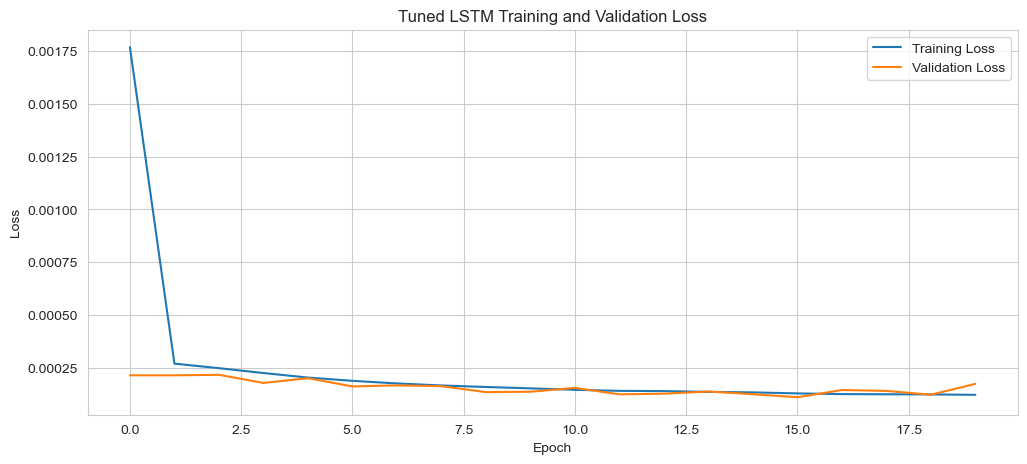

In [53]:
plt.figure(figsize=(12,5))

plt.plot(
    best_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    best_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Tuned LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Tuned LSTM Training and Validation Loss

The training loss decreases sharply in the first epochs and then declines steadily, levelling off at roughly 1.3 × 10⁻⁴ (scaled units).

The validation loss stays low throughout, but it fluctuates from epoch to epoch (roughly between 1.1 × 10⁻⁴ and 2.6 × 10⁻⁴). The validation loss never rises steadily while the training loss falls, so there is no clear sign of overfitting. The fluctuations suggest that training could be made more stable with a learning-rate schedule or early stopping.

## 12.3 Tuned LSTM Actual vs Predicted Energy Consumption

The actual and predicted energy consumption values from the final tuned LSTM model are compared visually on the test dataset.


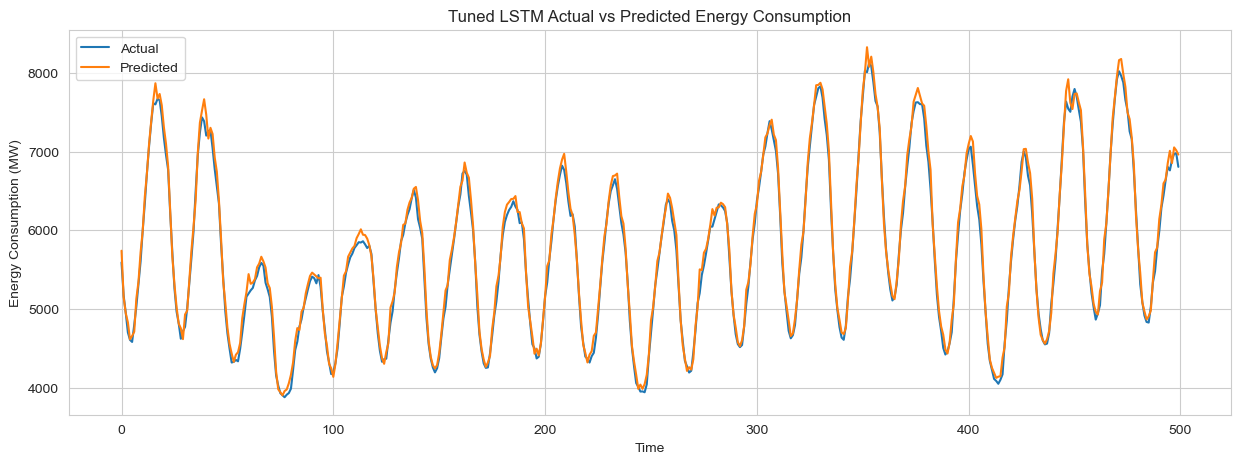

In [54]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test_actual[:500],
    label='Actual'
)

plt.plot(
    y_pred_tuned_actual[:500],
    label='Predicted'
)

plt.title('Tuned LSTM Actual vs Predicted Energy Consumption')
plt.xlabel('Time')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.grid(True)

plt.show()

### Tuned LSTM Actual vs Predicted Values

The plot shows the first 500 hours (about 3 weeks) of the test set. The predicted curve follows the actual curve very closely and reproduces the daily peaks and troughs as well as the day-to-day changes in level.

The model slightly under-predicts some of the highest daily peaks, which is typical for models trained with squared-error loss. This is consistent with the small MAE and MAPE values reported above.

## 12.4 Final Model Summary

Hyperparameter tuning was performed using different LSTM units, batch sizes, and learning rates. The configuration with the lowest recorded validation loss was selected and retrained on the training data.

### Selected Configuration
- **LSTM Units:** 64
- **Batch Size:** 64
- **Learning Rate:** 0.01
- **Input window:** previous 24 hours
- **Epochs (final model):** 20

### Final Test Performance (one-step-ahead, last one year)
- **MSE:** ≈ 6,275.30
- **RMSE:** ≈ 79.22 MW
- **MAE:** ≈ 60.56 MW
- **MAPE:** ≈ 1.07%

The tuned LSTM is carried forward as the final forecasting model for the required 30-day future energy consumption forecast.


## 13. 30-Day Future Energy Consumption Forecast

The **final tuned LSTM model** is used to forecast hourly energy consumption for the next 30 days. The forecast is generated **recursively**: each predicted value is fed back into the model as an input for the next prediction.

The forecast horizon covers **720 future hourly observations** (30 days) after the last available observation in the dataset (2018-08-03 00:00).

In [55]:
# 30-day forecast period

last_actual_time = df.index.max()

forecast_start = last_actual_time + pd.Timedelta(hours=1)

# 720 future hourly observations
forecast_dates = pd.date_range(
    start=forecast_start,
    periods=720,
    freq='h'
)

print("Last Actual Date :", last_actual_time)
print("Forecast Start   :", forecast_dates[0])
print("Forecast End     :", forecast_dates[-1])
print("Forecast Hours   :", len(forecast_dates))

Last Actual Date : 2018-08-03 00:00:00
Forecast Start   : 2018-08-03 01:00:00
Forecast End     : 2018-09-02 00:00:00
Forecast Hours   : 720


In [56]:
# Prepare the last 24 hours of actual data
last_24_hours = df[['PJMW_MW']].iloc[-24:].values
last_24_scaled = scaler.transform(last_24_hours)

current_sequence = last_24_scaled.flatten().tolist()
lstm_forecast_scaled = []

# Use the historical observed range as a safety bound for recursive forecasting.
# This prevents a single unstable recursive prediction from feeding an
# implausible value back into the next prediction.
historical_min = float(df['PJMW_MW'].min())
historical_max = float(df['PJMW_MW'].max())

# Generate 720 future hourly predictions
for i in range(len(forecast_dates)):

    input_sequence = np.array(
        current_sequence[-24:]
    ).reshape(1, 24, 1)

    next_prediction_scaled = best_model.predict(
        input_sequence,
        verbose=0
    )[0, 0]

    # Convert the prediction to MW, apply the historical-range guardrail,
    # then scale it again before feeding it back to the LSTM.
    next_prediction_mw = scaler.inverse_transform(
        np.array([[next_prediction_scaled]])
    )[0, 0]

    next_prediction_mw = np.clip(
        next_prediction_mw,
        historical_min,
        historical_max
    )

    next_prediction_scaled = scaler.transform(
        np.array([[next_prediction_mw]])
    )[0, 0]

    lstm_forecast_scaled.append(next_prediction_scaled)
    current_sequence.append(next_prediction_scaled)

# Convert predictions back to MW
lstm_forecast = scaler.inverse_transform(
    np.array(lstm_forecast_scaled).reshape(-1, 1)
).flatten()

print("Number of LSTM forecast values:", len(lstm_forecast))
print("Historical forecast guardrail (MW):", historical_min, "to", historical_max)


Number of LSTM forecast values: 720
Historical forecast guardrail (MW): 2553.0 to 9594.0


In [57]:
lstm_forecast_df = pd.DataFrame(
    {
        'Datetime': forecast_dates,
        'Forecast_MW': lstm_forecast
    }
)

lstm_forecast_df.set_index(
    'Datetime',
    inplace=True
)

print(lstm_forecast_df.head())
print()
print(lstm_forecast_df.tail())

                     Forecast_MW
Datetime                        
2018-08-03 01:00:00  5166.678711
2018-08-03 02:00:00  4988.711914
2018-08-03 03:00:00  4914.902832
2018-08-03 04:00:00  4926.393555
2018-08-03 05:00:00  5062.835938

                     Forecast_MW
Datetime                        
2018-09-01 20:00:00  9495.421875
2018-09-01 21:00:00  9328.548828
2018-09-01 22:00:00  9132.607422
2018-09-01 23:00:00  8963.994141
2018-09-02 00:00:00  8858.639648


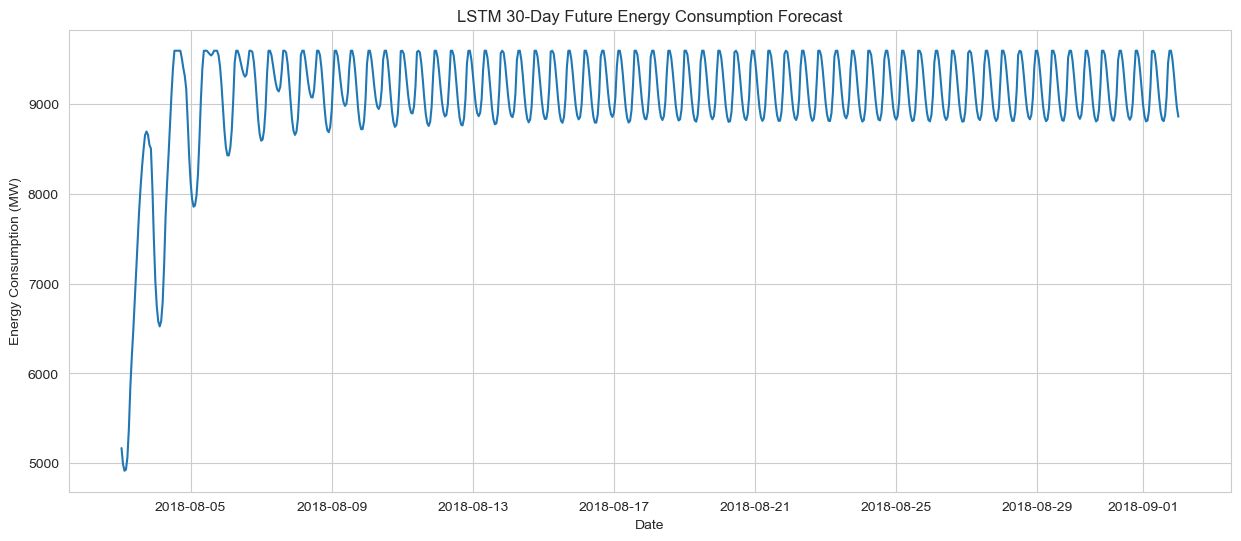

In [58]:
plt.figure(figsize=(15, 6))

plt.plot(
    lstm_forecast_df.index,
    lstm_forecast_df['Forecast_MW']
)

plt.title(
    'LSTM 30-Day Future Energy Consumption Forecast'
)

plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')

plt.grid(True)
plt.show()

In [59]:
print("LSTM 30-Day Forecast Summary")
print("----------------------------")

print(
    "Forecast Start :",
    lstm_forecast_df.index.min()
)

print(
    "Forecast End   :",
    lstm_forecast_df.index.max()
)

print(
    "Forecast Hours :",
    len(lstm_forecast_df)
)

print(
    "Average Forecast Consumption (MW) :",
    lstm_forecast_df['Forecast_MW'].mean()
)

print(
    "Maximum Forecast Consumption (MW) :",
    lstm_forecast_df['Forecast_MW'].max()
)

print(
    "Minimum Forecast Consumption (MW) :",
    lstm_forecast_df['Forecast_MW'].min()
)

LSTM 30-Day Forecast Summary
----------------------------
Forecast Start : 2018-08-03 01:00:00
Forecast End   : 2018-09-02 00:00:00
Forecast Hours : 720
Average Forecast Consumption (MW) : 9087.632
Maximum Forecast Consumption (MW) : 9594.0
Minimum Forecast Consumption (MW) : 4914.90283203125


### Forecast Observations

The 30-day forecast contains **720 future hourly observations**, beginning one hour after the last available observation.

The forecast is generated recursively: after the first predicted hour, each prediction is fed back into the 24-hour input window for the next prediction.

A historical-range guardrail is applied during recursive forecasting so that an unstable prediction cannot produce physically implausible values far outside the observed demand range. This is a practical safeguard; it does not add new information to the model.

The forecast should therefore be interpreted as a **30-day indicative demand profile**. Because the model is univariate and uses only the previous 24 hours, long-horizon forecasts can lose weekly and seasonal information. Calendar and weather variables are not included in the LSTM inputs.


## 14. Saving the Model and Scaler for Deployment

For deployment, the trained model and the fitted scaler must be saved together. The scaler is required to convert new input data to the same scale used in training and to convert predictions back to MW.

In [60]:
import joblib

# Save the trained LSTM model and the fitted MinMaxScaler
best_model.save('pjm_lstm_model.keras')
joblib.dump(scaler, 'pjm_scaler.pkl')

# Save the 30-day forecast for reporting
lstm_forecast_df.to_csv('pjm_30day_forecast.csv')

print('Saved: pjm_lstm_model.keras')
print('Saved: pjm_scaler.pkl')
print('Saved: pjm_30day_forecast.csv')


Saved: pjm_lstm_model.keras
Saved: pjm_scaler.pkl
Saved: pjm_30day_forecast.csv


### Using the Saved Model

To make predictions later, load the model and scaler, scale the **last 24 hourly values**, reshape them to `(1, 24, 1)`, call `model.predict`, and convert the result back to MW with `scaler.inverse_transform`.

## 16. Conclusion

The PJM hourly energy consumption series is cleaned, sorted, checked for duplicate timestamps and missing hours, and prepared for forecasting. A single implausibly low observation was treated as a data-quality issue and interpolated.

**Key findings from the analysis**

- Demand follows a clear daily cycle, with lower demand during the early morning and higher demand in the evening.
- Weekday demand is higher than weekend demand.
- Monthly and seasonal patterns are present, with winter and summer showing different demand profiles.
- Holiday demand is slightly lower than non-holiday demand in this dataset.
- The series is statistically stationary according to the ADF test while still showing strong daily and weekly seasonal structure.

**Model**

- The final model is a **Tuned LSTM** using 24-hour input sequences.
- Selected configuration: **64 LSTM units, batch size 64, learning rate 0.01**.
- On the one-year test set, the recorded run achieved an **RMSE of ≈ 79.22 MW, MAE of ≈ 60.56 MW, and MAPE of ≈ 1.07%** for one-step-ahead forecasting.

**30-day forecast**

- The tuned LSTM generates the required **720-hour (30-day)** forecast recursively.
- A historical-range guardrail is used to prevent implausible recursive values.
- The forecast is intended as an indicative future demand profile. Improving long-horizon accuracy would require longer input windows, calendar/weather features, and direct multi-step forecasting.

The trained LSTM model and fitted scaler are also saved in the deployment section.
